# Assignment 2: Architecture Showdown - Fixed GA vs Fluid GP (Modules 2, 3)

## The Scenario
Welcome back to **Synthetica**. The Global Defense Initiative has commissioned you to build the AI control system for a kinetic energy stabilization platform. The platform must perfectly balance a heavy inverted pendulum on a moving cart to maintain a target lock.

The sensors provide you with 4 inputs: Cart Position, Cart Velocity, Pole Angle, and Pole Velocity. Your AI must process these inputs and output a binary decision: apply force to the **Left (0)** or **Right (1)**.

In this capstone assignment, you will attempt to solve this environment using two drastically different evolutionary paradigms:
1. **Part 1 (Fixed Architecture):** You will use the skills you learned in Module 2 to build a continuous-parameter Genetic Algorithm from scratch. You will evolve the weights of a rigid, predefined Neural Network.
2. **Part 2 (Fluid Architecture):** You will use the skills from Module 3 to deploy `neat-python`, a state-of-the-art library that evolves both the weights *and* the underlying topology of the network.

## Understanding the CartPole-v1 Environment

Before we begin optimizing our AI, let's familiarize ourselves with the `CartPole-v1` environment provided by Gymnasium.

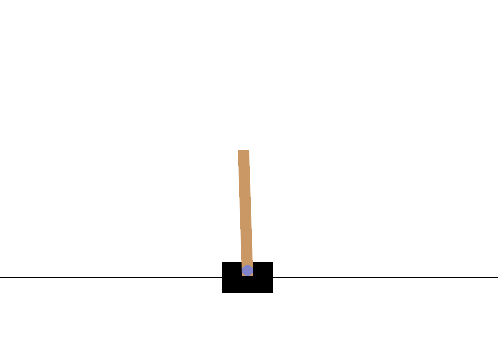

**Observation Space (State):**
The environment returns an array of 4 floating-point numbers representing the current physical state:
1. **Cart Position:** The horizontal position of the cart.
2. **Cart Velocity:** The speed at which the cart is moving left or right.
3. **Pole Angle:** The angle of the pole in radians (0 is perfectly vertical).
4. **Pole Angular Velocity:** The speed at which the pole is falling.

**Action Space:**
Your AI must output a single discrete integer each step:
* `0`: Push the cart to the **left**.
* `1`: Push the cart to the **right**.

**Goal:**
You receive a reward of +1 for every step the pole remains upright. The episode ends if the pole leans too far (more than 12 degrees), the cart moves off-screen, or the system successfully survives for 500 steps.

In [ ]:
!pip install gymnasium > /dev/null 2>&1
import gymnasium as gym

# Initialize the environment
env = gym.make('CartPole-v1')
state, info = env.reset()
print(f"Initial State Array: {state}")

# Sample a random action (0 or 1)
random_action = env.action_space.sample()
action_name = 'Right' if random_action == 1 else 'Left'
print(f"\nTaking Random Action: {random_action} ({action_name})")

# Step the physics engine forward by one frame
next_state, reward, terminated, truncated, info = env.step(random_action)

print(f"Next State Array: {next_state}")
print(f"Reward received: {reward}")
print(f"Did the platform crash? (Terminated): {terminated}")

env.close()

## Milestone 1: Set Up

*Run this cell to load the `simulate_cartpole` function. This function takes your chromosome of 25 floats, runs it through the Gym physics engine, and returns the total time steps the pole stayed balanced (up to a maximum of 500). You will complete the `feedforward_pass` function in Milestone 1.*

In [ ]:
# MILESTONE 1 SETUP - RUN THIS CELL FIRST
import random
import math

def simulate_cartpole(chromosome, render=False):
    """
    Simulates one episode of CartPole.
    Relies on the student's feedforward_pass() function to make decisions.
    """
    env = gym.make('CartPole-v1')
    state, _ = env.reset()
    total_reward = 0

    # Unpack the flat chromosome into two weight matrices
    # W1 is 4x5 (Inputs to Hidden), W2 is 5x1 (Hidden to Output)
    W1 = [chromosome[i:i+5] for i in range(0, 20, 5)]
    W2 = chromosome[20:25]

    done = False
    while not done and total_reward < 500:

        # --- THIS CALLS THE STUDENT'S FUNCTION ---
        action = feedforward_pass(state, W1, W2)

        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

    env.close()
    return total_reward

print("Synthetica Environment Loop Loaded.")

## Milestone 1: The Fixed-Weight Genetic Algorithm
**Objective:** You will build a GA to optimize a simple Neural Network with 4 input nodes, 5 hidden nodes, and 1 output node. Because we are omitting biases to keep the math simple, this network requires exactly **25 weights** (4x5 = 20 connections to the hidden layer, and 5x1 = 5 connections to the output layer).

Unlike Lab 2 (where DNA was integers), your chromosomes here will be arrays of 25 **floating-point numbers**.

### The Architect's Blueprint
*Write the continuous GA operators and the main execution loop to train your network.*

* **0. The Neural Network (Feedforward):** Write `feedforward_pass(state, W1, W2)`.
    * *Hidden Layer:* Create an empty list called `hidden`. For each of the 5 hidden nodes, calculate the dot product of the 4 `state` inputs and the node's corresponding 4 weights in `W1`. Apply a **ReLU activation** (if the sum is less than 0, set it to 0) and append it to `hidden`.
    * *Output Layer:* Calculate the dot product of the 5 `hidden` values and the 5 weights in `W2`.
    * *Activation & Action:* Apply a **Sigmoid activation** to the output sum: `prob = 1.0 / (1.0 + math.exp(-out_sum))`. *(Hint: cap out_sum between -500 and 500 to prevent math overflow errors).* If `prob > 0.5`, return `1` (Right). Otherwise, return `0` (Left).
* **1. Initializer:** Write `generate_chromosome()`. Return a list of 25 random floats between `-1.0` and `1.0`.
* **2. Crossover:** Write `uniform_crossover(parent1, parent2)`. Loop 25 times. At each index, flip a coin. If heads, append the gene from `parent1` to the child; if tails, append from `parent2`. Return **one** child array.
* **3. Mutation:** Write `gaussian_mutation(chromosome, rate)`. Loop through the chromosome. If a random roll is less than `rate`, do not replace the gene with a new number. Instead, *nudge* it by adding Gaussian noise: `chromosome[i] += random.gauss(0, 0.5)`. Return the mutated chromosome.
* **4. The Main Loop:** Write `run_fixed_ga(pop_size, generations, mutation_rate)`.
    * Initialize a population of `pop_size`.
    * Loop for `generations`:
        * Evaluate the fitness of every chromosome using our provided `simulate_cartpole(chrom)` function.
        * Sort the population from highest fitness to lowest.
        * *Early Stopping:* If the best fitness hits `500.0` (a perfect score), print the generation and stop the loop.
        * Keep a percentage of the population unchanged (Elitism).
        * Fill the rest of the new population by selecting two random parents from the top 50%, crossing them over to make a child, mutating the child, and appending it.
    * Return the single best chromosome found and its fitness score.

In [ ]:
# ENTER YOUR CODE HERE

### The Test Harness
*Run this code to deploy your Fixed-Weight GA. We will give it a population of 50 and let it run for up to 30 generations.*


In [ ]:
# MILESTONE 1 TEST HARNESS

print("Initializing Fixed-Weight GA Engine...")
best_weights, best_score = run_fixed_ga(
    pop_size=15,
    generations=30,
    mutation_rate=0.1
)

print("\n--- EVOLUTION HALTED ---")
print(f"Final Fitness Score: {best_score} / 500.0 steps")

if best_score == 500.0:
    print("SUCCESS: The Fixed-Weight GA successfully stabilized the CartPole platform!")
else:
    print("WARNING: The platform crashed. Try tweaking the hyper-parameters or rerunning.")

### Architect's Audit (Milestone 1)

1. **Continuous vs. Discrete Mutation:** In Lab 2 (N-Drones), you mutated DNA by completely replacing an integer with a brand-new random integer. In this milestone, you used **Gaussian Noise** to simply *nudge* the floating-point weights by a small amount. Conceptually, why is "nudging" weights mathematically better for Neural Networks than completely randomizing them?
2. **The Guessing Game:** For this milestone, you were forced to use exactly 5 hidden nodes. What is the fundamental danger of hard-coding the network architecture before training begins? What happens if you guess an architecture that is too small, or an architecture that is too large?

ENTER YOUR ANSWERS HERE

## Milestone 2: Set Up
*Run this cell to install the `neat-python` library and automatically generate the `config-feedforward.txt` file required by the library. We have pre-configured the hyper-parameters for you (e.g., population size, mutation rates, and compatibility thresholds).*



In [ ]:
# MILESTONE 2 SETUP - RUN THIS CELL FIRST
!pip install neat-python > /dev/null 2>&1
import neat
import os

In [ ]:
# Create the NEAT configuration file required by the library
config_text = """
[NEAT]
fitness_criterion       = max
fitness_threshold       = 500
no_fitness_termination  = False
pop_size                = 15
reset_on_extinction     = False

[DefaultGenome]
# node activation options
activation_default      = sigmoid
activation_mutate_rate  = 0.0
activation_options      = sigmoid

# node aggregation options
aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

# node bias options
bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

# genome compatibility options
compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

# connection add/remove rates
conn_add_prob           = 0.5
conn_delete_prob        = 0.5

# connection enable options
enabled_default         = True
enabled_mutate_rate     = 0.01

feed_forward            = True
initial_connection      = full_direct

# node add/remove rates
node_add_prob           = 0.2
node_delete_prob        = 0.2

# network parameters
num_hidden              = 0
num_inputs              = 4
num_outputs             = 1

# node response options
response_init_mean      = 1.0
response_init_stdev     = 0.0
response_max_value      = 30.0
response_min_value      = -30.0
response_mutate_power   = 0.0
response_mutate_rate    = 0.0
response_replace_rate   = 0.0

# connection weight options
weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_max_value        = 30.0
weight_min_value        = -30.0
weight_mutate_power     = 0.5
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.1

[DefaultSpeciesSet]
compatibility_threshold = 2.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 20
species_elitism      = 2

[DefaultReproduction]
elitism            = 2
survival_threshold = 0.2
"""

with open("config-feedforward.txt", "w") as f:
    f.write(config_text)

print("Synthetica NEAT Engine & Configuration Loaded.")

## Milestone 2: NeuroEvolution of Augmenting Topologies (NEAT)
**Objective:** You built a highly capable GA in Milestone 1, but you had to mathematically *guess* that 5 hidden nodes would be the optimal architecture. What if the optimal architecture is actually 0 hidden nodes? Or 12?

In this milestone, you will abandon the fixed-weight approach and deploy `neat-python`. This state-of-the-art library evolves the network's weights *and* its topological structure from the ground up, starting with zero hidden nodes and slowly mutating to add complexity only if it improves the fitness!

### The Architect's Blueprint
*You must write the custom fitness evaluation function and the main NEAT execution loop.*

* **1. The Fitness Evaluator:** Write `eval_genomes(genomes, config)`.
    * *Note on NEAT API:* The `genomes` parameter passed to this function is a list of tuples `(genome_id, genome)`.
    * Loop through `for genome_id, genome in genomes:`.
    * For each genome, set its initial `genome.fitness = 0`.
    * Create the neural network using `net = neat.nn.FeedForwardNetwork.create(genome, config)`.
    * Set up your `gym.make('CartPole-v1')` environment and start the `while` loop (exactly like you did in Milestone 1).
    * Inside the gym loop, pass the current environment `state` to the network using `output = net.activate(state)`.
    * The `output` is a list (even though we only have 1 output node). Grab `output[0]`. If it is `> 0.5`, set `action = 1`. Else, `action = 0`.
    * Step the environment. For every step the pole stays upright, add `1` to `genome.fitness`. Stop if `genome.fitness` hits `500`.
* **2. The Execution Loop:** Write `run_neat(config_file)`.
    * Load the NEAT configuration using `config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction, neat.DefaultSpeciesSet, neat.DefaultStagnation, config_file)`.
    * Create the population using `p = neat.Population(config)`.
    * Add a reporter so we can see the terminal output: `p.add_reporter(neat.StdOutReporter(True))`.
    * Run the algorithm by calling `winner = p.run(eval_genomes, 50)` (where 50 is the max generations).
    * Return the `winner` genome.

In [ ]:
# ENTER YOUR CODE HERE

### The Test Harness
*Run this code to deploy NEAT! Watch the terminal output carefully—you will see the algorithm splitting your networks into different "Species" to protect structural innovation.*

In [ ]:
# MILESTONE 2 TEST HARNESS

print("Initializing NeuroEvolution of Augmenting Topologies (NEAT)...")

# Run the NEAT algorithm
winning_genome = run_neat("config-feedforward.txt")

print("\n--- EVOLUTION HALTED ---")
print(f"Target Locked! Best Genome ID: {winning_genome.key}")
print(f"Final Fitness Score: {winning_genome.fitness}")
print(f"Network Structure: {len(winning_genome.nodes)} hidden nodes, {len(winning_genome.connections)} connections.")

if winning_genome.fitness >= 500.0:
    print("SUCCESS: NEAT successfully stabilized the CartPole platform!")
else:
    print("WARNING: The platform crashed. Try rerunning the evolution.")

### Architect's Audit (Milestone 2)

1. **The Architecture Revelation:** Look at the printout for the "Network Structure" in your Test Harness. How many hidden nodes did NEAT actually need to solve the environment? Compare this to the architecture you were forced to use in Milestone 1. What are the advantages (or disadvantages) of the network architecture found by NEAT?
2. **Speciation in the Terminal:** Scroll up through the terminal output generated by the `StdOutReporter`. Notice how the population is divided into different "species" with varying sizes. Based on Module 3, mathematically explain how the `compatibility_threshold` (which we set to 2.0 in the config file) decides whether a newly mutated network gets to form its own species or gets lumped in with the others.

ENTER YOUR ANSWERS HERE

## Milestone 3: Set Up

*Google Colab runs on headless Linux servers. Calling standard physical window renders will crash your notebook. Run this cell to install a virtual display buffer and a few popular visualization libraries. From here, the implementation is up to you!*

In [ ]:
# MILESTONE 3 SETUP - RUN THIS CELL FIRST
!apt-get update > /dev/null 2>&1
!apt-get install -y xvfb python-opengl graphviz > /dev/null 2>&1
!pip install pyvirtualdisplay imageio imageio-ffmpeg graphviz networkx > /dev/null 2>&1

from pyvirtualdisplay import Display
import matplotlib.pyplot as plt
import networkx as nx
import imageio
import graphviz

# Start the virtual display buffer (Required for Gym's rgb_array render mode)
virtual_display = Display(visible=0, size=(400, 300))
virtual_display.start()

print("Synthetica Virtual Buffer Active. Visualization libraries loaded.")

## Milestone 3: Visualization & Topological Analysis

**Objective:** Seeing the fitness score reach 500 is satisfying, but observing your AI physically control the kinetic platform is the ultimate payoff. Furthermore, as an AI engineer, you must be able to visually communicate *why* one architecture is better than another to stakeholders.

In this open-ended milestone, you are tasked with building your own visualization suite. You must write functions to render the physical behavior of your agents (e.g., as GIFs or MP4s) and generate network graphs to map their "brain" topologies.

### The Architect's Blueprint

*Your objective is to write four visualization functions. You may use any combination of `imageio`, `matplotlib`, `networkx`, `graphviz`, or HTML embeddings to achieve this.*

* **1. Behavioral Renders:** Write `render_fixed_agent(chromosome)` and `render_neat_agent(genome, config)`.
* *Hint:* When creating your Gymnasium environment, use `env = gym.make('CartPole-v1', render_mode='rgb_array')`.
* Inside your evaluation loop, use `frame = env.render()` to capture the current state of the screen as an array of pixels. Store these frames in a list.
* Use a library like `imageio.mimsave()` to stitch your list of frames together into a `.mp4` or `.gif` file, and find a way to display it in your notebook.


* **2. Topological Graphs:** Write `visualize_fixed_topology()` and `visualize_neat_topology(genome, config)`.
* *Fixed GA:* Generate a visual graph of a fully connected network with 4 input nodes, 5 hidden nodes, and 1 output node (25 total edges).
* *NEAT GA:* Parse the `genome.nodes` and `genome.connections` to dynamically draw exactly what the algorithm evolved. (Green lines for positive weights, red for negative weights is a nice touch!).
* *Hint:* `networkx` is great for quick node-edge plotting in `matplotlib`, while `graphviz` is excellent for clean, hierarchical diagrams.

In [ ]:
# ENTER YOUR CODE HERE

### The Test Harness

*Use this cell to execute your functions. Your output should clearly display the physical behavior videos and the architectural graphs for both agents.*

In [ ]:
# MILESTONE 3 TEST HARNESS

print("--- 1. FIXED-WEIGHT GA VISUALIZATION ---")
# Call your fixed GA behavioral render here
# 1. Render the Fixed GA Agent
# (Assumes the variable from Milestone 1 was named best_overall_chromosome or best_weights)
print("Rendering Fixed-Weight Agent...")
render_fixed_agent(best_weights, filename="fixed_agent.mp4")

# Call your fixed GA topology graph here
visualize_fixed_topology()


In [ ]:
print("\n--- 2. NEAT GA VISUALIZATION ---")
# Call your NEAT behavioral render here
# 3. Render the NEAT Agent
config = neat.Config(
    neat.DefaultGenome,
    neat.DefaultReproduction,
    neat.DefaultSpeciesSet,
    neat.DefaultStagnation,
    "config-feedforward.txt"
)
print("Rendering NEAT Agent...")
render_neat_agent(winning_genome, config, filename="neat_agent.mp4")

In [ ]:
# Call your NEAT topology graph here
# 4. Visualize the Evolved Topology
print("Generating NEAT Topology Graph...")
visualize_neat_topology(winning_genome, config)

### Architect's Audit (Milestone 3)

1. **Behavioral Analysis:** Watch your two custom renders closely. Did the two algorithms develop different physical strategies for balancing the pole?
2. **Visualizing Occam's Razor:** Compare the two topology graphs you generated. How does physically seeing the massive, dense web of the 5-node Fixed GA compare to the highly sparse, evolved NEAT graph?

ENTER YOUR ANSWERS HERE

## The Sprint Review (Video Submission & Audit Summary)

To complete the Assignment, you must submit your final Colab Notebook and record a **3-to-5 minute maximum** video presentation of your screen.

Assume your audience contains both technical engineering directors and non-technical military procurement executives of the *Global Defense Initiative* who are evaluating your AI for physical deployment.

**Your presentation must address the following prompts using visual evidence from your Colab notebook:**

1. **Continuous Evolution (The Mathematical Nudge):** In Lab 2 (N-Drones), your GA mutated DNA by completely replacing discrete integers with brand-new numbers. In Milestone 1 of this assignment, you used arrays of floating-point numbers. Explain to the executives why you had to use "Gaussian Noise" to slightly *nudge* the neural network weights instead of completely randomizing them. How does this prevent the AI from instantly forgetting its learned logic?
2. **Occam's Razor & Hardware Deployment:** Show the two Topology Graphs you generated in Milestone 3. First, show the dense, tangled web of the Fixed GA (the 25 weights you were forced to guess). Then, show the highly sparse architecture evolved by NEAT. Explain the concept of "Occam's Razor" in Machine Learning. Why makes NEAT's minimal, fluid approach vastly superior for deploying AI onto edge-computing physical hardware (like a kinetic stabilization platform) with limited battery and processing power?
3. **The Protection of Innovation (Speciation):** Show the `StdOutReporter` terminal logs from your NEAT run in Milestone 2. Point out the "Species" columns and the "Mean genetic distance." Explain the core dilemma of topology evolution: why does adding a brand-new, highly innovative node temporarily ruin a network's performance? Mathematically explain how the Compatibility Distance threshold ($\delta$) protects these new, poorly performing architectures from being instantly deleted by the older, highly optimized clones.